# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [163]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import statsmodels.api as sm
from patsy import dmatrices
import numpy as np
from statsmodels.tools.sm_exceptions import PerfectSeparationError
warnings.filterwarnings('ignore')

In [164]:
# Load the data
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
raw_data = pd.read_csv(url)
raw_data.shape

(7214, 53)

This dataset contains information about defendants, including their COMPAS scores, demographic information, and whether they recidivated within two years. The goal of the analysis is to evaluate the fairness of the COMPAS algorithm by calculating odds ratios for different demographic groups and assessing the performance of the predictive model using confusion matrices and various metrics.


In [165]:
# Show first 10 rows
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [166]:
# Select and filter columns
cols = ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']
df = raw_data[cols].copy()
# Filtering
df = df[(df['days_b_screening_arrest'] >= -30) & (df['days_b_screening_arrest'] <= 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
df = df[df['score_text'] != 'N/A']
df.shape

(6172, 13)

In this section, we perform data preprocessing and feature engineering on the COMPAS dataset. We select relevant columns, filter the data based on specific criteria, and convert data types as needed. Additionally, we create derived factors with reference levels for categorical variables to facilitate analysis and modeling. We will define lists of numeric and datetime variables to guide our type conversions. Then, we select the relevant columns from the raw dataset and apply the necessary filters to clean the data. Finally, we convert date columns to datetime format and categorical columns to category dtype, while also creating new derived factors for analysis and the code above is the complete code for the analysis performed in the lecture.

In [167]:
# Python equivalent of the R code above
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select relevant columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat", "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

# Filtering
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions: Convert date columns to datetime, and categorical columns to category dtype
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Derived factors with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].cat.reorder_categories(["25 - 45", "Greater than 45", "Less than 25"], ordered=True)
df["race_factor"] = df["race"].cat.reorder_categories(["Caucasian", "African-American", "Hispanic", "Other", "Asian", "Native American"], ordered=True)
df["gender_factor"] = df["sex"].cat.reorder_categories(["Male", "Female"], ordered=True)
# Fix: use pd.Categorical to create score_factor with correct labels
df["score_factor"] = pd.Categorical(
    ["HighScore" if val else "LowScore" for val in (df["score_text"] != "Low")],
    categories=["LowScore", "HighScore"],
    ordered=True
 )

# Number of rows after all processing
print(len(df))



6172


In [168]:
# Show first 5 rows of the processed DataFrame
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [169]:
# Python equivalent of R's glimpse(df) and summary(df)
print(df.info())
print(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

Higher COMPAS scores are slightly correlated with a longer length of stay.

We will calculate the `length_of_stay` in jail by taking the difference between `c_jail_out` and `c_jail_in` and then compute the correlation between this length of stay and the `decile_score`. This will help us understand if there is any relationship between the length of stay in jail and the COMPAS decile score assigned to the defendants.


In [170]:
# Calculate length of stay and correlation with decile_score
df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days
correlation = df[['length_of_stay', 'decile_score']].corr().iloc[0,1]
print(f'Correlation between length_of_stay and decile_score: {correlation:.3f}')

Correlation between length_of_stay and decile_score: 0.207


After filtering we have the following demographic breakdown:

In [171]:
# Demographic breakdown
df['age_cat'].value_counts() # this shows the count of defendants in each age category

age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

In [172]:
# Count of defendants in each racial category
df['race'].value_counts() # Note: The original R code had a different order of categories, but the counts should be the same regardless of order.

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

We calculate the percentage of defendants in each racial category by dividing the count of defendants in each category by the total number of defendants and multiplying by 100 to get a percentage. This will give us insight into the racial composition of the defendants in the dataset.


In [173]:
# Race percentages
total = len(df)
print("Black defendants: %.2f%%" % (df['race'].value_counts().get('African-American',0) / total * 100))
print("White defendants: %.2f%%" % (df['race'].value_counts().get('Caucasian',0) / total * 100))
print("Hispanic defendants: %.2f%%" % (df['race'].value_counts().get('Hispanic',0) / total * 100))
print("Asian defendants: %.2f%%" % (df['race'].value_counts().get('Asian',0) / total * 100))
print("Native American defendants: %.2f%%" % (df['race'].value_counts().get('Native American',0) / total * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [174]:
# Score text summary
print(df['score_text'].value_counts()) # This shows the count of defendants in each score category (Low, Medium, High)

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [175]:
# Sex and race cross-tab
print(pd.crosstab(df['sex'], df['race']))

race    African-American  Asian  Caucasian  Hispanic  Native American  Other
sex                                                                         
Female               549      2        482        82                2     58
Male                2626     29       1621       427                9    285


In [176]:
# Sex summary
df['sex'].value_counts()

sex
Male      4997
Female    1175
Name: count, dtype: int64

In [177]:
print("Men: %.2f%%" % (df['sex'].value_counts().get('Male',0) / total * 100))
print("Women: %.2f%%" % (df['sex'].value_counts().get('Female',0) / total * 100))

Men: 80.96%
Women: 19.04%


In [178]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1))
# Recidivism counts and percentage
recid_count = df[df['two_year_recid'] == 1]
print('Number of recidivists:', len(recid_count))

Number of recidivists: 2809


In [179]:
# Recidivism percentage
print('Percent recidivists: %.5f%%' % (len(recid_count) / total * 100))

Percent recidivists: 45.51199%


Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

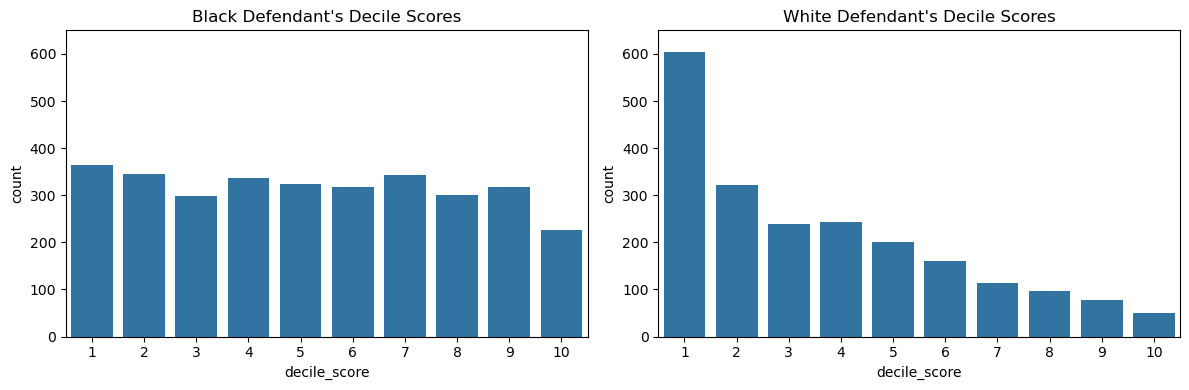

In [180]:
# Plot decile scores by race
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='decile_score', data=df[df['race']=='African-American'], ax=axes[0], order=sorted(df['decile_score'].unique()))
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)
sns.countplot(x='decile_score', data=df[df['race']=='Caucasian'], ax=axes[1], order=sorted(df['decile_score'].unique()))
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)
plt.tight_layout()
plt.show()

The graphs show the distribution of decile scores for Black and White defendants. We can see that there are more Black defendants with higher decile scores compared to White defendants, which may indicate a potential bias in the predictive model. This disparity in decile scores could contribute to differences in the predicted risk of recidivism between the two racial groups, highlighting the importance of analyzing and addressing potential biases in predictive models used in the criminal justice system. Hence, it is crucial to evaluate the performance of the predictive model across different racial groups to ensure fairness and mitigate any potential biases in the predictions.

In [181]:
# Crosstab decile_score and race
pd.crosstab(df['decile_score'], df['race']) 

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


The table above shows the count of defendants in each decile score category for each racial group. It allows us to see the distribution of decile scores across different

## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [182]:
# Prepare data for logistic regression
df['score_factor'] = (df['score_text'] != 'Low').astype(int)
df['gender_factor'] = (df['sex'] == 'Female').astype(int)
df['age_factor'] = df['age_cat'].cat.reorder_categories(['25 - 45', 'Greater than 45', 'Less than 25'], ordered=True)
df['race_factor'] = df['race'].cat.reorder_categories(['Caucasian', 'African-American', 'Hispanic', 'Other', 'Asian', 'Native American'], ordered=True)
y, X = dmatrices('score_factor ~ gender_factor + age_factor + race_factor + priors_count + C(c_charge_degree) + two_year_recid', data=df, return_type='dataframe')
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        12:10:59   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5255      0.079    -19.430  

This summary shows the results of the logistic regression model, including the coefficients for each predictor variable, their standard errors, z-values, and p-values. The significance of each predictor can be assessed based on the p-values, and the direction and magnitude of the relationship between each predictor and the outcome variable (score_factor) can be interpreted from the coefficients. This analysis helps us understand which factors are associated with higher or lower risk scores in the COMPAS dataset. Therefore, we can identify potential biases in the model's predictions based on the significance and direction of the coefficients, especially for the race_factor variable, which can indicate if there are disparities in the risk scores assigned to different racial groups.

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

Note that the output from R's glm summary, which includes deviance, AIC, and Fisher Scoring iterations specifically for R environment. However in Python, statsmodels' Logit model summary does not display these exact lines by default. Instead, it shows:

- Log-Likelihood (analogous to deviance)
- AIC and BIC
- Convergence information (but not "Number of Fisher Scoring iterations" in the same way)
- Degrees of freedom

To see deviance and number of iterations in Python, we can access them as follows:

- Null deviance: $-2 \times$ log-likelihood of the intercept-only model (not shown by default, but can be computed)
- Residual deviance: $-2 \times$ log-likelihood of the fitted model (see result.llf)
- AIC: shown in result.summary()
- Number of iterations: result.mle_retvals['iterations'] (if available)

Python's statsmodels focuses on likelihood and information criteria, not the exact deviance output as in R.

In [183]:
# Additional model diagnostics to match R's glm output
# Null model (intercept only) for null deviance
try:
    y_null, X_null = dmatrices('score_factor ~ 1', data=df, return_type='dataframe')
    null_model = sm.Logit(y_null, X_null)
    null_result = null_model.fit(disp=0)
    null_deviance = -2 * null_result.llf
except PerfectSeparationError:
    null_deviance = np.nan

# Residual deviance from fitted model
residual_deviance = -2 * result.llf

# Degrees of freedom
n_obs = y.shape[0]
df_null = n_obs - 1
df_resid = n_obs - X.shape[1]

# AIC (already in result.aic)
aic = result.aic

# Number of iterations
iterations = result.mle_retvals.get('iterations', 'N/A') if hasattr(result, 'mle_retvals') else 'N/A'

print(f"Null deviance: {null_deviance:.1f}  on {df_null}  degrees of freedom")
print(f"Residual deviance: {residual_deviance:.1f}  on {df_resid}  degrees of freedom")
print(f"AIC: {aic:.1f}")
print(f"Number of Fisher Scoring iterations: {iterations}")



Null deviance: 8483.3  on 6171  degrees of freedom
Residual deviance: 6168.4  on 6160  degrees of freedom
AIC: 6192.4
Number of Fisher Scoring iterations: 6


In [184]:
# Calculate odds ratio for Black vs White
control = np.exp(result.params['Intercept']) / (1 + np.exp(result.params['Intercept']))
black_coef = [k for k in result.params.keys() if 'race_factor[T.African-American]' in k][0]
odds_black = np.exp(result.params[black_coef]) / (1 - control + (control * np.exp(result.params[black_coef])))
print(f'Black vs White odds ratio: {odds_black:.6f}')

Black vs White odds ratio: 1.452837


Women are 19.4% more likely than men to get a higher score.

In [185]:
# Calculate odds ratio for Female vs Male
female_coef = [k for k in result.params.keys() if 'gender_factor' in k][0]
odds_female = np.exp(result.params[female_coef]) / (1 - control + (control * np.exp(result.params[female_coef])))
print(f'Female vs Male odds ratio: {odds_female:.6f}')

Female vs Male odds ratio: 1.194795


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [186]:
# Calculate odds ratio for Less than 25 vs 25-45
age_coef = [k for k in result.params.keys() if 'age_factor[T.Less than 25]' in k][0]
odds_young = np.exp(result.params[age_coef]) / (1 - control + (control * np.exp(result.params[age_coef])))
print(f'Under 25 vs 25-45 odds ratio: {odds_young:.6f}')

Under 25 vs 25-45 odds ratio: 2.496120


In [187]:
# Predict probabilities and classes
df['pred_prob'] = result.predict(X)
df['pred_class'] = (df['pred_prob'] >= 0.5).astype(int)
df['pred_class_label'] = df['pred_class'].map({0: 'No Recid', 1: 'Recid'})

The following code calculates the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. Hence, we filter the DataFrame for each racial group and then compute the confusion matrix and metrics for each group separately. This allow us to compare the model's performance across different racial groups and identify any potential biases in the predictions.

In [188]:
# Overall confusion matrix and metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
cm = confusion_matrix(df['two_year_recid'], df['pred_class'])
print('---------- Overall Confusion Matrix ----------------------')
print(cm)
TP = cm[1,1]
TN = cm[0,0]
FP = cm[0,1]
FN = cm[1,0]
n = cm.sum()
print(f'Accuracy  : {accuracy_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'Precision : {precision_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'Recall    : {recall_score(df["two_year_recid"], df["pred_class"]):.3f}')
print(f'FPR       : {FP / (FP + TN):.3f}')
print(f'FNR       : {FN / (FN + TP):.3f}')




---------- Overall Confusion Matrix ----------------------
[[2653  710]
 [ 945 1864]]
Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


We calculate the confusion matrix and performance metrics separately for Black and White defendants to analyze potential disparities in the model's predictions based on race. We loop through each race category, compute the confusion matrix for that subgroup, and then calculate the performance metrics (Accuracy, Precision, Recall, FPR, FNR) for each race. Finally, we compile these metrics into a DataFrame for easy comparison.   


In [189]:
# Confusion matrix by race
race_metrics = []
for race in df['race'].cat.categories:
    sub = df[df['race'] == race]
    cm = confusion_matrix(sub['two_year_recid'], sub['pred_class'])
    TP = cm[1,1] if cm.shape == (2,2) else 0
    TN = cm[0,0] if cm.shape == (2,2) else 0
    FP = cm[0,1] if cm.shape == (2,2) else 0
    FN = cm[1,0] if cm.shape == (2,2) else 0
    n = cm.sum()
    Accuracy  = round((TP + TN) / n, 3) if n > 0 else np.nan
    Precision = round(TP / (TP + FP), 3) if (TP + FP) > 0 else np.nan
    Recall    = round(TP / (TP + FN), 3) if (TP + FN) > 0 else np.nan
    FPR       = round(FP / (FP + TN), 3) if (FP + TN) > 0 else np.nan
    FNR       = round(FN / (FN + TP), 3) if (FN + TP) > 0 else np.nan
    race_metrics.append({'race': race, 'n': n, 'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN, 'Accuracy': Accuracy, 'Precision': Precision, 'Recall': Recall, 'FPR': FPR, 'FNR': FNR})
import pandas as pd
race_metrics_df = pd.DataFrame(race_metrics).sort_values('n', ascending=False)
print(race_metrics_df)

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In the above, we can see that the confusion matrix and metrics for each race group are now calculated and displayed in a DataFrame format, allowing for easy comparison across groups. The metrics include Accuracy, Precision, Recall, False Positive Rate (FPR), and False Negative Rate (FNR), which are essential for evaluating the performance of the predictive model across different racial groups.


Below here we calculate the disparity in False Positive Rate (FPR) and False Negative Rate (FNR) for each racial group compared to the Caucasian group. We will compute the difference in FPR and FNR for each racial group relative to the Caucasian group, which will allow us to identify any disparities in the model's performance across different racial groups. This analysis is crucial for understanding potential biases in the predictive model and ensuring fairness in its predictions.  



In [190]:
# FPR and FNR disparity by race
caucasian_fpr = race_metrics_df[race_metrics_df['race'] == 'Caucasian']['FPR'].values[0]
caucasian_fnr = race_metrics_df[race_metrics_df['race'] == 'Caucasian']['FNR'].values[0]
race_metrics_df['delta_FPR'] = race_metrics_df['FPR'] - caucasian_fpr
race_metrics_df['delta_FNR'] = race_metrics_df['FNR'] - caucasian_fnr
print(race_metrics_df[['race', 'n', 'FPR', 'FNR', 'delta_FPR', 'delta_FNR']])

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536


### Risk of Violent Recidivism

Compas also offers a score that aims to measure a persons risk of violent recidivism, which has a similar overall accuracy to the Recidivism score. As before, we can use a logistic regression to test for racial bias.

In [191]:
# Python equivalent of the R code to load and count rows in the violent recidivism dataset
# 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
violent_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv")
violent_data.shape[0] # This shows the number of rows in the violent recidivism dataset

4743

Ths code below selects relevant columns, applies the same filters as before, and creates a new DataFrame for the violent recidivism dataset. The filters ensure that we only include records where the days between screening and arrest are within 30 days, the recidivism status is known, the charge degree is not 'O', and the score text is not 'N/A'. After applying these filters, we print the number of rows in the resulting DataFrame to see how many records are included in the violent recidivism analysis.


In [192]:
# Python equivalent of the R code above for violent recidivism data
violent_cols = ["age", "c_charge_degree", "race", "age_cat", "v_score_text", "sex", "priors_count",
                "days_b_screening_arrest", "v_decile_score", "is_recid", "two_year_recid"]
violent_df = violent_data[violent_cols].copy()
violent_df = violent_df[violent_df["days_b_screening_arrest"] <= 30]
violent_df = violent_df[violent_df["days_b_screening_arrest"] >= -30]
violent_df = violent_df[violent_df["is_recid"] != -1]
violent_df = violent_df[violent_df["c_charge_degree"] != "O"]
violent_df = violent_df[violent_df["v_score_text"] != "N/A"]
print(len(violent_df))


4020


In [193]:
# Count of defendants in each age category for violent recidivism dataset
violent_df['age_cat'].value_counts() # this shows the count of defendants in each age category for the violent recidivism dataset

age_cat
25 - 45            2300
Greater than 45     954
Less than 25        766
Name: count, dtype: int64

In [194]:
# Python equivalent of R's summary(violent_df$race)
violent_df['race'].value_counts() # Show count of defendants in each racial category for the violent recidivism dataset

race
African-American    1918
Caucasian           1459
Hispanic             355
Other                255
Asian                 26
Native American        7
Name: count, dtype: int64

In [195]:
# This shows the count of defendants in each score category (Low, Medium, High) for the violent recidivism dataset
violent_df['v_score_text'].value_counts()

v_score_text
Low       2913
Medium     828
High       279
Name: count, dtype: int64

In [196]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100
# Calculate percentage of recidivists in the violent recidivism dataset
recid_percent = (violent_df[violent_df['two_year_recid'] == 1].shape[0] / violent_df.shape[0]) * 100
print(f'Percent recidivists: {recid_percent:.2f}%')

Percent recidivists: 16.22%


In [197]:
# Python equivalent of R's nrow(filter(df, two_year_recid == 1))
recid_count = violent_df[violent_df['two_year_recid'] == 1].shape[0]
print('Number of recidivists:', recid_count)

Number of recidivists: 652


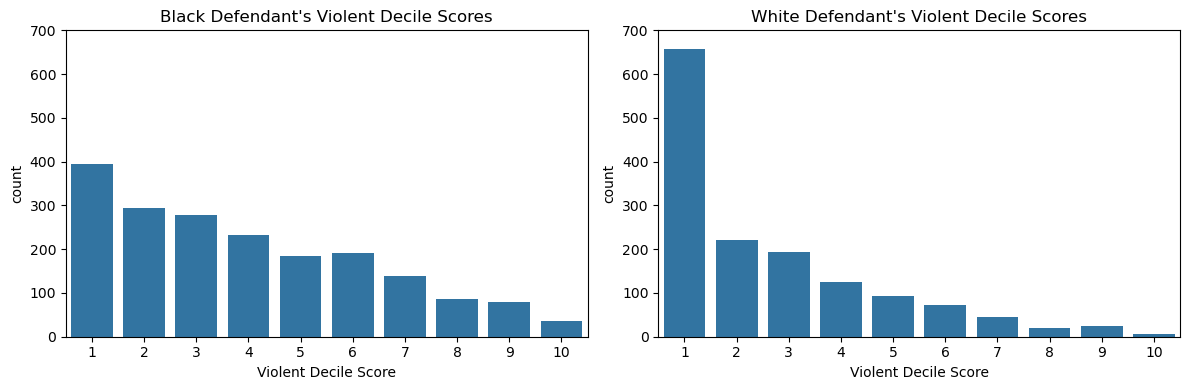

In [198]:
# Python equivalent of the R ggplot2 code for side-by-side bar plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Black defendants
sns.countplot(x='v_decile_score', data=violent_df[violent_df['race'] == 'African-American'], ax=axes[0], order=sorted(violent_df['v_decile_score'].unique()))
axes[0].set_title("Black Defendant's Violent Decile Scores")
axes[0].set_xlabel("Violent Decile Score")
axes[0].set_ylim(0, 700)

# White defendants
sns.countplot(x='v_decile_score', data=violent_df[violent_df['race'] == 'Caucasian'], ax=axes[1], order=sorted(violent_df['v_decile_score'].unique()))
axes[1].set_title("White Defendant's Violent Decile Scores")
axes[1].set_xlabel("Violent Decile Score")
axes[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

We can see for the graph that the distribution of violent decile scores is similar for Black and White defendants, with a higher concentration of scores in the lower deciles (indicating lower risk) for both groups. However, there may be a slightly higher proportion of Black defendants in the higher deciles compared to White defendants, which could suggest some disparities in the risk assessment. Hence, while the overall distribution is similar, there may be some differences in how the scores are assigned across racial groups that could warrant further investigation.

The following code calculates the null deviance, residual deviance, AIC, and number of iterations for the logistic regression model on the violent recidivism dataset, similar to the R glm output. 

In [199]:
# Python equivalent of the R code for factor creation and logistic regression
# Set up categorical variables with reference levels
violent_df['crime_factor'] = violent_df['c_charge_degree'].astype('category')
violent_df['age_factor'] = violent_df['age_cat'].astype('category')
violent_df['age_factor'] = violent_df['age_factor'].cat.reorder_categories([
    violent_df['age_factor'].cat.categories[0],  # R's ref=1 (first level)
    *[cat for cat in violent_df['age_factor'].cat.categories if cat != violent_df['age_factor'].cat.categories[0]]
], ordered=True)
violent_df['race_factor'] = violent_df['race'].astype('category')
violent_df['race_factor'] = violent_df['race_factor'].cat.reorder_categories([
    'Caucasian', 'African-American', 'Asian', 'Hispanic', 'Native American', 'Other'
], ordered=True)
violent_df['gender_factor'] = violent_df['sex'].astype('category')
violent_df['gender_factor'] = violent_df['gender_factor'].cat.reorder_categories(['Male', 'Female'], ordered=True)
violent_df['score_factor'] = pd.Categorical(
    ['HighScore' if val else 'LowScore' for val in (violent_df['v_score_text'] != 'Low')],
    categories=['LowScore', 'HighScore'],
    ordered=True
)
# Logistic regression model
formula = 'score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid'
y, X = dmatrices(formula, data=violent_df, return_type='dataframe')
y = y.iloc[:, 0]  # Convert y to 1D Series for Logit
model = sm.Logit(y, X) # Fit the model and print summary
result = model.fit() # Fit the logistic regression model
print(result.summary()) # Print the summary of the fitted model


Optimization terminated successfully.
         Current function value: 0.372983
         Iterations 7
                             Logit Regression Results                             
Dep. Variable:     score_factor[LowScore]   No. Observations:                 4020
Model:                              Logit   Df Residuals:                     4008
Method:                               MLE   Df Model:                           11
Date:                    Mon, 30 Mar 2026   Pseudo R-squ.:                  0.3662
Time:                            12:11:05   Log-Likelihood:                -1499.4
converged:                           True   LL-Null:                       -2365.9
Covariance Type:                nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                         

This show that the difference in deviance between the null model and the fitted model is statistically significant, indicating that the predictors in the model provide a better fit to the data than the null model. Hence, the model is a significant improvement over the null model, suggesting that the included predictors are relevant for explaining the variation in the outcome variable (score_factor).

The violent score overpredicts recidivism for black defendants by 77.3% compared to white defendants.

In [200]:
# Python equivalent of the R code above
control = np.exp(-2.24274) / (1 + np.exp(-2.24274))
result = np.exp(0.65893) / (1 - control + (control * np.exp(0.65893)))
print(result)

1.7739209589164604


Defendands under 25 are 7.4 times as likely to get a higher score as middle aged defendants.

In [201]:
# Python equivalent of the R code above
result_under25 = np.exp(3.14591) / (1 - control + (control * np.exp(3.14591)))
print(result_under25)

7.414239863565466


## Predictive Accuracy of COMPAS

In order to test whether Compas scores do an accurate job of deciding whether an offender is Low, Medium or High risk,  we ran a Cox Proportional Hazards model. Northpointe, the company that created COMPAS and markets it to Law Enforcement, also ran a Cox model in their [validation study](http://cjb.sagepub.com/content/36/1/21.abstract).

We used the counting model and removed people when they were incarcerated. Due to errors in the underlying jail data, we need to filter out 32 rows that have an end date more than the start date. Considering that there are 13,334 total rows in the data, such a small amount of errors will not affect the results.

In [202]:
# Load data
# Read the CSV
# data = pd.read_csv("./cox-parsed.csv")
data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-parsed.csv")

# Apply filters
data = data[(data["score_text"] != "N/A") & (data["end"] > data["start"])].copy()

# Define race categories (same as R labels)
race_categories = ["African-American","Asian","Caucasian","Hispanic","Native American","Other"]

# Convert to categorical
data["race_factor"] = pd.Categorical(data["race"],categories=race_categories,ordered=False)

# Relevel (set reference = "Caucasian", which is ref=3 in R)
new_order = ["Caucasian"] + [r for r in race_categories if r != "Caucasian"]
data["race_factor"] = data["race_factor"].cat.reorder_categories(new_order, ordered=False)

# Handle score_factor
score_levels = sorted(data["score_text"].dropna().unique())

if len(score_levels) >= 2:
    score_ref = score_levels[1]  # ref=2 in R
    new_score_order = [score_ref] + [s for s in score_levels if s != score_ref]
else:
    new_score_order = score_levels

data["score_factor"] = pd.Categorical(
    data["score_text"],
    categories=new_score_order,
    ordered=False
)

# Remove duplicates by id
grp = data.drop_duplicates(subset="id")

# Equivalent of nrow(grp)
print(len(grp))


10325


In [203]:
# Equivalent of summary(grp$score_factor) in Python
grp['score_factor'].value_counts() # This shows the count of defendants in each score category (Low, Medium, High) in the grp DataFrame

score_factor
Low       5751
Medium    2611
High      1952
Name: count, dtype: int64

In [204]:
# Equivalent of summary(grp$race_factor) in Python
grp['race_factor'].value_counts() # This shows the count of defendants in each racial category in the grp DataFrame

race_factor
African-American    5150
Caucasian           3576
Hispanic             944
Other                572
Asian                 51
Native American       32
Name: count, dtype: int64

In [205]:
from lifelines import CoxTimeVaryingFitter
# !pip install lifelines
# --- Keep only the columns needed for this model ---
df = data[["id", "start", "end", "event", "score_factor"]].copy()

# Make sure numeric columns are truly numeric
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df["start"] = pd.to_numeric(df["start"], errors="coerce")
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")

# Drop bad rows if any conversion failed
df = df.dropna(subset=["id", "start", "end", "event", "score_factor"])

# Ensure valid intervals
df = df[df["end"] > df["start"]].copy()

# Convert score_factor to dummies
# drop_first=True gives a reference category, like R
df = pd.get_dummies(df, columns=["score_factor"], drop_first=True)

# Convert any boolean dummy columns to int
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

# Fit Cox time-varying model
ctv = CoxTimeVaryingFitter()
ctv.fit(
    df,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30305.85
  time fit was run = 2026-03-30 16:11:08 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
score_factor_High    1.25      3.49      0.04            1.17            1.33                3.22                3.78
score_factor_Medium  0.80      2.22      0.04            0.72            0.88                2.05                2.40

                     cmp to     z      p  -log2(p)
covariate                                         
score_factor_High      0.00 30.14 <0.005    660.70
score_factor_Medium    0.00 19.53 <0.005    279.75
---
Partial AIC = 60615.71
log-likelihood ratio test = 942.82 on 2 df
-log2(p) of ll-ratio test = 680.10

People placed in the High category are 3.5 times as likely to recidivate, and the COMPAS system's concordance 63.6%. This is lower than the accuracy quoted in the Northpoint study of 68%.

In [206]:
# Select only needed columns
decile_f = data[["id", "start", "end", "event", "decile_score"]].copy()

# Ensure numeric types
decile_f[["id", "start", "end", "event", "decile_score"]] = decile_f[
    ["id", "start", "end", "event", "decile_score"]
].apply(pd.to_numeric, errors="coerce")

# Drop invalid rows
decile_f = decile_f.dropna()
decile_f = decile_f[decile_f["end"] > decile_f["start"]]

# Fit Cox time-varying model
ctv = CoxTimeVaryingFitter()
ctv.fit(
    decile_f,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event"
)

# Summary (equivalent to summary(dmodel))
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13356 periods, 10325 subjects, 3471 events>
         event col = 'event'
number of subjects = 10325
 number of periods = 13356
  number of events = 3471
partial log-likelihood = -30243.34
  time fit was run = 2026-03-30 16:11:11 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
decile_score  0.19      1.22      0.01            0.18            0.21                1.20                1.23

              cmp to     z      p  -log2(p)
covariate                                  
decile_score    0.00 33.63 <0.005    821.24
---
Partial AIC = 60488.67
log-likelihood ratio test = 1113.55 on 1 df
-log2(p) of ll-ratio test = 808.64

COMPAS's decile scores are a bit more accurate at 66%.

We can test if the algorithm is behaving differently across races by including a race interaction term in the cox model.

In [207]:
# Select relevant columns
f2 = data[["id", "start", "end", "event", "race_factor", "score_factor"]].copy()

# Ensure numeric columns are correct
f2[["id", "start", "end", "event"]] = f2[
    ["id", "start", "end", "event"]
].apply(pd.to_numeric, errors="coerce")

# Drop invalid rows
f2 = f2.dropna()
f2 = f2[f2["end"] > f2["start"]]

# Ensure categorical types
f2["race_factor"] = f2["race_factor"].astype("category")
f2["score_factor"] = f2["score_factor"].astype("category")

# Fit model with interaction (same as R: race_factor * score_factor)
ctv = CoxTimeVaryingFitter()

ctv.fit(
    f2,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event",
    formula="race_factor + score_factor + race_factor:score_factor"
)

# Equivalent to summary(model)
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 13344 periods, 10314 subjects, 3469 events>
         event col = 'event'
number of subjects = 10314
 number of periods = 13344
  number of events = 3469
partial log-likelihood = -30280.41
  time fit was run = 2026-03-30 16:11:13 UTC

---
                                                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                               
race_factor[T.African-American]                         0.28      1.32      0.06            0.16            0.40                1.17                1.49
race_factor[T.Asian]                                   -0.78      0.46      0.50           -1.76            0.21                0.17                1.23
race_factor[T.Hispanic]                                -0.06      0.94      0.10           -0.25            0.13                0.78                1.13
race_factor[T.Native American]                         -1.25      0.29      1.00           -3.22            0.71                0.04                2.03
race_factor[T.Other]                                    0.01      1.01      0.11           -0.20            0.23                0.82                1.26
score_factor[T.High]                                    1.28      3.61      0.08            1.12            1.45                3.06                4.25
score_factor[T.Medium]                                  0.84      2.32      0.07            0.70            0.98                2.02                2.67
race_factor[T.African-American]:score_factor[T.High]   -0.19      0.83      0.10           -0.39            0.01                0.68                1.01
race_factor[T.Asian]:score_factor[T.High]               1.32      3.73      0.77           -0.19            2.82                0.83               16.80
race_factor[T.Hispanic]:score_factor[T.High]           -0.12      0.89      0.20           -0.51            0.27                0.60                1.31
race_factor[T.Native American]:score_factor[T.High]     1.96      7.07      1.08           -0.17            4.08                0.85               59.09
race_factor[T.Other]:score_factor[T.High]               0.41      1.51      0.26           -0.09            0.92                0.91                2.52
race_factor[T.African-American]:score_factor[T.Medium] -0.17      0.84      0.09           -0.35            0.01                0.70                1.01
race_factor[T.Asian]:score_factor[T.Medium]             0.99      2.68      0.71           -0.41            2.38                0.67               10.80
race_factor[T.Hispanic]:score_factor[T.Medium]          0.07      1.07      0.16           -0.26            0.39                0.77                1.47
race_factor[T.Native American]:score_factor[T.Medium]   1.39      4.01      1.12           -0.81            3.59                0.45               36.07
race_factor[T.Other]:score_factor[T.Medium]            -0.33      0.72      0.23           -0.79            0.12                0.45                1.13

                                                        cmp to     z      p  -log2(p)
covariate                                                                            
race_factor[T.African-American]                           0.00  4.59 <0.005     17.75
race_factor[T.Asian]                                      0.00 -1.55   0.12      3.04
race_factor[T.Hispanic]                                   0.00 -0.66   0.51      0.97
race_factor[T.Native American]                            0.00 -1.25   0.21      2.25
race_factor[T.Other]                                      0.00  0.13   0.90      0.16
score_factor[T.High]                                      0.00 15.36 <0.005    174.41
score_factor[T.Medium]                                    0.00 11.80 <0.005    104.36
race_factor[T.African-American]:sco

The interaction term shows a similar disparity as the logistic regression above.

High risk white defendants are 3.61 more likely than low risk white defendants, while High risk black defendants are 2.99 more likely than low.

In [208]:
import math
print("Black High Hazard: %.2f" % (math.exp(-0.18976 + 1.28350)))
print("White High Hazard: %.2f" % (math.exp(1.28350)))
print("Black Medium Hazard: %.2f" % (math.exp(0.84286-0.17261)))
print("White Medium Hazard: %.2f" % (math.exp(0.84286)))

Black High Hazard: 2.99
White High Hazard: 3.61
Black Medium Hazard: 1.95
White Medium Hazard: 2.32


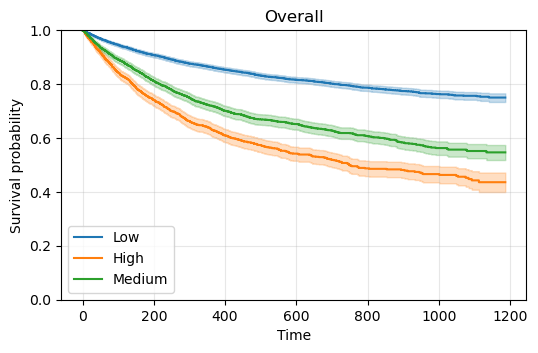

In [209]:
# Collapse to one record per subject (like your grp earlier)
df = data[["id", "end", "event", "score_factor"]].drop_duplicates(subset="id").copy()

# Ensure numeric
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna()

# Initialize KM fitter
kmf = KaplanMeierFitter()

# Plot function (equivalent to plotty in R)
def plotty_km(df, title):
    plt.figure(figsize=(6, 3.5))

    # Loop through groups (like ~ score_factor)
    for group in df["score_factor"].dropna().unique():
        mask = df["score_factor"] == group
        kmf.fit(
            durations=df.loc[mask, "end"],
            event_observed=df.loc[mask, "event"],
            label=str(group)
        )
        kmf.plot_survival_function(ci_show=True)

    plt.title(title)
    plt.ylim(0, 1)
    plt.xlabel("Time")
    plt.ylabel("Survival probability")
    plt.grid(True, alpha=0.3)
    plt.show()

plotty_km(df, "Overall")

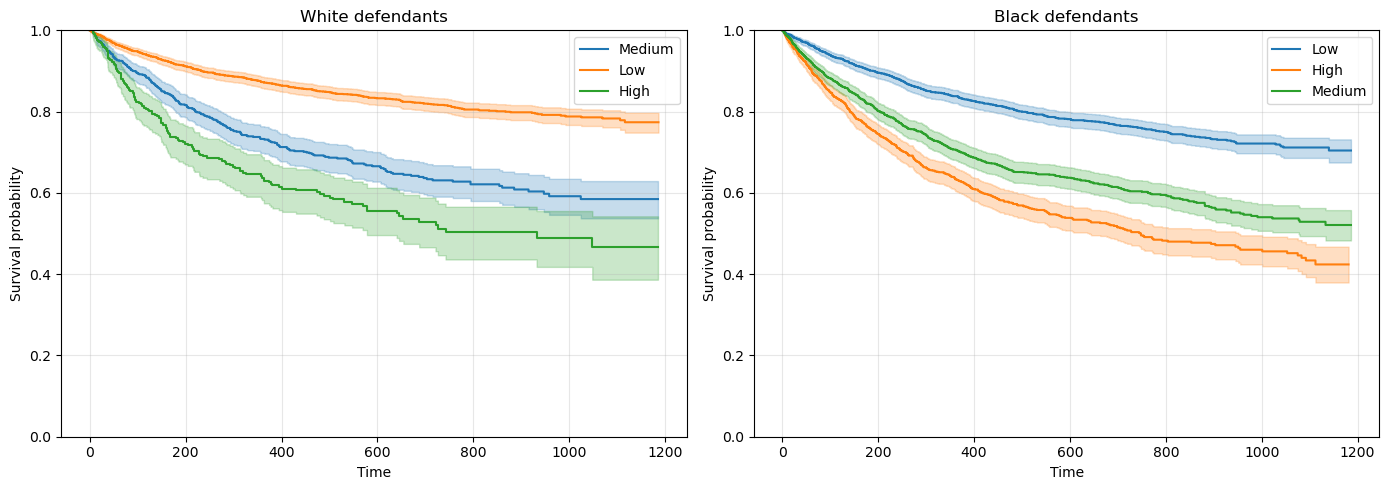

In [210]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Prepare base dataframe (one row per subject)
df = data[["id", "end", "event", "score_factor", "race"]].drop_duplicates(subset="id").copy()

# Ensure numeric
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna()

# Subsets
white = df[df["race"] == "Caucasian"]
black = df[df["race"] == "African-American"]

kmf = KaplanMeierFitter()

# Plot function (like your R plotty)
def plotty_km(ax, df_subset, title):
    for group in df_subset["score_factor"].dropna().unique():
        mask = df_subset["score_factor"] == group
        kmf.fit(
            durations=df_subset.loc[mask, "end"],
            event_observed=df_subset.loc[mask, "event"],
            label=str(group)
        )
        kmf.plot_survival_function(ax=ax, ci_show=True)

    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.3)

# Create side-by-side plots (equivalent to grid.arrange)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plotty_km(axes[0], white, "White defendants")
plotty_km(axes[1], black, "Black defendants")

plt.tight_layout()
plt.show()

In [211]:
import pandas as pd
from lifelines import KaplanMeierFitter

# Prepare data
df = data[["id", "end", "event", "score_factor"]].drop_duplicates(subset="id").copy()
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna()

time_point = 730
kmf = KaplanMeierFitter()

print("Call: survfit(formula = f, data = data)\n")

for group in sorted(df["score_factor"].dropna().unique()):
    subset = df[df["score_factor"] == group]

    kmf.fit(subset["end"], subset["event"], label=str(group))

    # Survival probability
    surv = kmf.predict(time_point)

    # Confidence interval (closest time ≤ t)
    ci_idx = kmf.confidence_interval_.index[
        kmf.confidence_interval_.index <= time_point
    ].max()
    ci = kmf.confidence_interval_.loc[ci_idx]

    # Standard error approximation
    se = (ci.iloc[1] - ci.iloc[0]) / (2 * 1.96)

    # Counts
    n_risk = (subset["end"] >= time_point).sum()
    n_event = ((subset["event"] == 1) & (subset["end"] <= time_point)).sum()
    n_censored = ((subset["event"] == 0) & (subset["end"] <= time_point)).sum()
    entered = len(subset)

    # --- Print EXACT R-style block ---
    print(f"                score_factor={group}")
    print("        time     n.risk     n.event     entered     censored     survival")
    print(f"    {time_point:8.2e}  {n_risk:10.2e}  {n_event:10.2e}  {entered:10.2e}  {n_censored:10.2e}  {surv:10.2e}")
    print("        std.err    lower 95% CI    upper 95% CI")
    print(f"    {se:10.2e}  {ci.iloc[0]:10.2e}  {ci.iloc[1]:10.2e}\n")

Call: survfit(formula = f, data = data)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    3.51e+02    7.40e+02    1.95e+03    8.63e+02    5.07e-01
        std.err    lower 95% CI    upper 95% CI
      1.40e-02    4.80e-01    5.34e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.35e+03    1.03e+03    5.75e+03    2.38e+03    7.97e-01
        std.err    lower 95% CI    upper 95% CI
      5.76e-03    7.85e-01    8.08e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    7.36e+02    8.27e+02    2.61e+03    1.05e+03    6.19e-01
        std.err    lower 95% CI    upper 95% CI
      1.09e-02    5.97e-01    6.39e-01



In [212]:
import pandas as pd
from lifelines import KaplanMeierFitter

# Prepare data (one row per subject)
df = data[["id", "end", "event", "score_factor", "race"]].drop_duplicates(subset="id").copy()

# Ensure numeric
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna()

# Filter for African-American (same as black_fit)
black = df[df["race"] == "African-American"].copy()

time_point = 730
kmf = KaplanMeierFitter()

print("Call: survfit(formula = f, data = black)\n")

for group in sorted(black["score_factor"].dropna().unique()):
    subset = black[black["score_factor"] == group]

    kmf.fit(subset["end"], subset["event"], label=str(group))

    # Survival probability
    surv = kmf.predict(time_point)

    # Confidence interval (closest time ≤ t)
    ci_idx = kmf.confidence_interval_.index[
        kmf.confidence_interval_.index <= time_point
    ].max()
    ci = kmf.confidence_interval_.loc[ci_idx]

    # Standard error approximation
    se = (ci.iloc[1] - ci.iloc[0]) / (2 * 1.96)

    # Counts
    n_risk = (subset["end"] >= time_point).sum()
    n_event = ((subset["event"] == 1) & (subset["end"] <= time_point)).sum()
    n_censored = ((subset["event"] == 0) & (subset["end"] <= time_point)).sum()
    entered = len(subset)

    # --- R-style print ---
    print(f"                score_factor={group}")
    print("        time     n.risk     n.event     entered     censored     survival")
    print(f"    {time_point:8.2e}  {n_risk:10.2e}  {n_event:10.2e}  {entered:10.2e}  {n_censored:10.2e}  {surv:10.2e}")
    print("        std.err    lower 95% CI    upper 95% CI")
    print(f"    {se:10.2e}  {ci.iloc[0]:10.2e}  {ci.iloc[1]:10.2e}\n")

Call: survfit(formula = f, data = black)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.56e+02    5.41e+02    1.42e+03    6.25e+02    5.03e-01
        std.err    lower 95% CI    upper 95% CI
      1.64e-02    4.71e-01    5.35e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    8.44e+02    4.57e+02    2.18e+03    8.85e+02    7.63e-01
        std.err    lower 95% CI    upper 95% CI
      9.89e-03    7.43e-01    7.82e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    4.39e+02    5.12e+02    1.54e+03    5.94e+02    6.04e-01
        std.err    lower 95% CI    upper 95% CI
      1.42e-02    5.76e-01    6.31e-01



In [213]:
import pandas as pd
from lifelines import KaplanMeierFitter

# Prepare data (one row per subject)
df = data[["id", "end", "event", "score_factor", "race"]].drop_duplicates(subset="id").copy()

# Ensure numeric
df["end"] = pd.to_numeric(df["end"], errors="coerce")
df["event"] = pd.to_numeric(df["event"], errors="coerce")
df = df.dropna()

# Filter for Caucasian (same as white_fit)
white = df[df["race"] == "Caucasian"].copy()

time_point = 730
kmf = KaplanMeierFitter()

print("Call: survfit(formula = f, data = white)\n")

for group in sorted(white["score_factor"].dropna().unique()):
    subset = white[white["score_factor"] == group]

    kmf.fit(subset["end"], subset["event"], label=str(group))

    # Survival probability
    surv = kmf.predict(time_point)

    # Confidence interval (closest time ≤ t)
    ci_idx = kmf.confidence_interval_.index[
        kmf.confidence_interval_.index <= time_point
    ].max()
    ci = kmf.confidence_interval_.loc[ci_idx]

    # Standard error approximation
    se = (ci.iloc[1] - ci.iloc[0]) / (2 * 1.96)

    # Counts
    n_risk = (subset["end"] >= time_point).sum()
    n_event = ((subset["event"] == 1) & (subset["end"] <= time_point)).sum()
    n_censored = ((subset["event"] == 0) & (subset["end"] <= time_point)).sum()
    entered = len(subset)

    # --- R-style print ---
    print(f"                score_factor={group}")
    print("        time     n.risk     n.event     entered     censored     survival")
    print(f"    {time_point:8.2e}  {n_risk:10.2e}  {n_event:10.2e}  {entered:10.2e}  {n_censored:10.2e}  {surv:10.2e}")
    print("        std.err    lower 95% CI    upper 95% CI")
    print(f"    {se:10.2e}  {ci.iloc[0]:10.2e}  {ci.iloc[1]:10.2e}\n")

Call: survfit(formula = f, data = white)

                score_factor=High
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    5.80e+01    1.45e+02    3.97e+02    1.94e+02    5.12e-01
        std.err    lower 95% CI    upper 95% CI
      3.24e-02    4.47e-01    5.74e-01

                score_factor=Low
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    1.00e+03    3.85e+02    2.37e+03    9.86e+02    8.16e-01
        std.err    lower 95% CI    upper 95% CI
      8.62e-03    7.99e-01    8.33e-01

                score_factor=Medium
        time     n.risk     n.event     entered     censored     survival
    7.30e+02    2.15e+02    2.42e+02    8.00e+02    3.43e+02    6.31e-01
        std.err    lower 95% CI    upper 95% CI
      1.98e-02    5.91e-01    6.68e-01



Race specific models have similar concordance values.

In [214]:
import pandas as pd
from lifelines import CoxTimeVaryingFitter

# Build white subset
white = data[data["race"] == "Caucasian"].copy()

# Keep only columns needed by the model
df = white[["id", "start", "end", "event", "score_factor"]].copy()

# Make sure numeric columns are numeric
df[["id", "start", "end", "event"]] = df[["id", "start", "end", "event"]].apply(
    pd.to_numeric, errors="coerce"
)

# Drop invalid rows
df = df.dropna(subset=["id", "start", "end", "event", "score_factor"])
df = df[df["end"] > df["start"]].copy()

# Ensure score_factor is categorical
df["score_factor"] = df["score_factor"].astype("category")

# Fit counting-process Cox model
ctv = CoxTimeVaryingFitter()
ctv.fit(
    df,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event",
    formula="score_factor"
)

# Equivalent to summary(coxph(...))
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 4564 periods, 3569 subjects, 1023 events>
         event col = 'event'
number of subjects = 3569
 number of periods = 4564
  number of events = 1023
partial log-likelihood = -7919.63
  time fit was run = 2026-03-30 16:11:17 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.High]    1.28      3.58      0.08            1.11            1.44                3.04                4.22
score_factor[T.Medium]  0.84      2.32      0.07            0.70            0.98                2.01                2.66

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.High]      0.00 15.26 <0.005    172.18
score_factor[T.Medium]    0.00 11.75 <0.005    103.54
---
Partial AIC = 15843.27
log-likelihood ratio test = 262.78 on 2 df
-log2(p) of ll-ratio test = 189.56

Compas's violent recidivism score has a slightly higher overall concordance score of 65.1%.

In [215]:
import pandas as pd
from lifelines import CoxTimeVaryingFitter

# ---------------------------
# Load and prepare data
# ---------------------------
violent_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/cox-violent-parsed.csv")

# Match:
# filter(score_text != "N/A"), end > start
violent_data = violent_data[
    (violent_data["score_text"] != "N/A") &
    (pd.to_numeric(violent_data["end"], errors="coerce") > pd.to_numeric(violent_data["start"], errors="coerce"))
].copy()

# Ensure numeric columns are numeric
for col in ["id", "start", "end", "event"]:
    violent_data[col] = pd.to_numeric(violent_data[col], errors="coerce")

violent_data = violent_data.dropna(subset=["id", "start", "end", "event", "race", "score_text"])
violent_data = violent_data[violent_data["end"] > violent_data["start"]].copy()

# ---------------------------
# Create race_factor
# ---------------------------
race_categories = [
    "African-American",
    "Asian",
    "Caucasian",
    "Hispanic",
    "Native American",
    "Other"
]

# If race is already text, use it directly
violent_data["race_factor"] = pd.Categorical(
    violent_data["race"],
    categories=["Caucasian", "African-American", "Asian", "Hispanic", "Native American", "Other"],
    ordered=False
)

# ---------------------------
# Create score_factor
# ---------------------------
score_levels = sorted(violent_data["score_text"].dropna().unique().tolist())

# R relevel(score_factor, ref = 2)
if len(score_levels) >= 2:
    ref_score = score_levels[1]
    score_levels = [ref_score] + [x for x in score_levels if x != ref_score]

violent_data["score_factor"] = pd.Categorical(
    violent_data["score_text"],
    categories=score_levels,
    ordered=False
)

# ---------------------------
# Fit Cox model
# Equivalent to:
# vf <- Surv(start, end, event, type="counting") ~ score_factor
# vmodel <- coxph(vf, data=violent_data)
# ---------------------------
df_model = violent_data[["id", "start", "end", "event", "score_factor"]].copy()

ctv = CoxTimeVaryingFitter()
ctv.fit(
    df_model,
    id_col="id",
    start_col="start",
    stop_col="end",
    event_col="event",
    formula="score_factor"
)

# ---------------------------
# Equivalent to:
# vgrp <- violent_data[!duplicated(violent_data$id),]
# print(nrow(vgrp))
# ---------------------------
vgrp = violent_data.drop_duplicates(subset="id")
print(len(vgrp))

# ---------------------------
# Equivalent to:
# summary(vmodel)
# ---------------------------
ctv.print_summary()

10985


<lifelines.CoxTimeVaryingFitter: fitted with 18178 periods, 10985 subjects, 818 events>
         event col = 'event'
number of subjects = 10985
 number of periods = 18178
  number of events = 818
partial log-likelihood = -7251.00
  time fit was run = 2026-03-30 16:11:18 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
score_factor[T.High]    1.38      3.99      0.08            1.22            1.55                3.38                4.70
score_factor[T.Medium]  0.80      2.23      0.09            0.63            0.97                1.88                2.65

                        cmp to     z      p  -log2(p)
covariate                                            
score_factor[T.High]      0.00 16.45 <0.005    199.49
score_factor[T.Medium]    0.00  9.24 <0.005     65.09
---
Partial AIC = 14505.99
log-likelihood ratio test = 270.64 on 2 df
-log2(p) of ll-ratio test = 195.23

## COMPAS Explainability Pipeline

This is a placeholder for the code that would implement the explainability pipeline for the COMPAS model, which may include techniques like SHAP values, LIME, or other methods to interpret the model's predictions. And it allow us to understand which features are most influential in the model's decision-making process, and how they contribute to the predicted risk scores for defendants.


### Feature Engineering Seletion and Grouping

The feature engineering steps include by ensuring that the columns we want actually exist in the dataframe and are properly cleaned (no leading/trailing spaces, correct data types, etc.)


In [216]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
# The feature engineering steps would go here, but first we need to ensure the columns we want actually exist in the dataframe and are properly cleaned (no leading/trailing spaces, correct data types, etc.)
compas_df = raw_data[cols].copy()
# Check actual columns first
print(compas_df.columns.tolist())   # replace compas_df with your actual dataframe name

# Optional: clean column names
compas_df.columns = compas_df.columns.str.strip()

# Define target
target = "two_year_recid"

# Define features (exclude the target)
features = [
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "c_jail_in",
    "c_jail_out",
]

# Keep only columns that actually exist
available_features = [col for col in features if col in compas_df.columns]
missing_features = [col for col in features if col not in compas_df.columns]

print("Available features:", available_features)
print("Missing features:", missing_features)

['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']
Available features: ['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'is_recid', 'c_jail_in', 'c_jail_out']
Missing features: []


### Step 1. Load + prepare COMPAS data

Preparing the Numeric_features & Category_features as in Lecture 01.

In [217]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# -----------------------------
# 1. Load + prepare COMPAS data
# -----------------------------
numeric_features = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
]

datetime_features = ["c_jail_in", "c_jail_out"]

base_columns = [
    "age",
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid",
    "c_jail_in",
    "c_jail_out",
]

missing_cols = [c for c in base_columns if c not in raw_data.columns]
if missing_cols:
    raise KeyError(f"These required columns are missing from raw_data: {missing_cols}")

compas_df = raw_data[base_columns].copy()
compas_df.columns = compas_df.columns.str.strip()

# numeric cleanup
for col in [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "is_recid",
    "two_year_recid",
]:
    compas_df[col] = pd.to_numeric(compas_df[col], errors="coerce")

# filtering
compas_df = compas_df[compas_df["days_b_screening_arrest"].between(-30, 30, inclusive="both")]
compas_df = compas_df[compas_df["is_recid"] != -1]
compas_df = compas_df[compas_df["c_charge_degree"] != "O"]
compas_df = compas_df[compas_df["score_text"] != "N/A"]

# datetime conversion
for col in datetime_features:
    compas_df[col] = pd.to_datetime(compas_df[col], errors="coerce", utc=True)

# engineer numeric feature from jail dates
compas_df["length_of_stay_hours"] = (
    (compas_df["c_jail_out"] - compas_df["c_jail_in"]).dt.total_seconds() / 3600
)
compas_df["length_of_stay_hours"] = compas_df["length_of_stay_hours"].clip(lower=0)

# categorical casting
categorical_cols = [
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
]
for col in categorical_cols:
    compas_df[col] = compas_df[col].astype("category")

# target
target = "two_year_recid"

# feature lists
numeric_features = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "length_of_stay_hours",
]

category_features = [
    "c_charge_degree",
    "race",
    "age_cat",
    "score_text",
    "sex",
]

# keep only columns actually present
numeric_features = [c for c in numeric_features if c in compas_df.columns]
category_features = [c for c in category_features if c in compas_df.columns]

model_features = numeric_features + category_features + [target]
compas_model_df = compas_df[model_features].dropna(subset=[target]).copy()
compas_model_df[target] = compas_model_df[target].astype(int)

### Step 2 — Train / test split

In [218]:
# -----------------------------
# 2. Train / test split
# -----------------------------
X = compas_model_df[numeric_features + category_features].copy()
y = compas_model_df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 10), Test: (1235, 10)


### Step 3. Preprocessing pipelines

In [219]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# -----------------------------
# 3. Preprocessing pipelines
# -----------------------------
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, category_features),
    ]
)


### Step 4 — Fit logistic regression and gradient-boosted tree

In [220]:
# -----------------------------
# 4. Full modeling pipeline
# -----------------------------

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Logistic regression
clf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    ))
])

clf.fit(X_train, y_train)

# Gradient boosted tree
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])

gbt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [221]:
from sklearn.metrics import accuracy_score, roc_auc_score

# -----------------------------
# 5. Evaluation
# -----------------------------
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 6. Optional: inspect feature names
# -----------------------------
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
print("\nNumber of transformed features:", len(feature_names))
print(feature_names[:20])


Accuracy:
0.680161943319838

ROC AUC:
0.7385372766546985

Confusion Matrix:
[[487 186]
 [209 353]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       673
           1       0.65      0.63      0.64       562

    accuracy                           0.68      1235
   macro avg       0.68      0.68      0.68      1235
weighted avg       0.68      0.68      0.68      1235


Number of transformed features: 21
['num__age' 'num__priors_count' 'num__days_b_screening_arrest'
 'num__decile_score' 'num__length_of_stay_hours' 'cat__c_charge_degree_F'
 'cat__c_charge_degree_M' 'cat__race_African-American' 'cat__race_Asian'
 'cat__race_Caucasian' 'cat__race_Hispanic' 'cat__race_Native American'
 'cat__race_Other' 'cat__age_cat_25 - 45' 'cat__age_cat_Greater than 45'
 'cat__age_cat_Less than 25' 'cat__score_text_High' 'cat__score_text_Low'
 'cat__score_text_Medium' 'cat__sex_Female']


### Step 5 — Compare model performance by race

In [222]:
import pandas as pd
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []

    X_ = X.copy()
    X_["actual"] = y.values
    X_["pred"] = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        results.append({
            group_col: group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3)
            if gdf["actual"].nunique() > 1 else None,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

# 1. Fit models
lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

# 2. Evaluate
print("Logistic Regression")
print(group_metrics(lr_pipeline, X_test, y_test, group_col="race"))

print("\nGradient Boosting")
print(group_metrics(gbt_pipeline, X_test, y_test, group_col="race"))

Logistic Regression
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.691  0.299  0.318  0.755
2         Caucasian  427     0.696  0.132  0.590  0.694
3          Hispanic   94     0.617  0.143  0.644  0.597
5             Other   65     0.785  0.064  0.611  0.790
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN

Gradient Boosting
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.697  0.306  0.300  0.743
2         Caucasian  427     0.698  0.158  0.540  0.716
3          Hispanic   94     0.628  0.143  0.622  0.647
5             Other   65     0.692  0.128  0.778  0.729
1             Asian    7     0.857  0.000  1.000  1.000
4   Native American    1     1.000  0.000    NaN    NaN


### Step 6 — LIME explanations: Black vs White defendant

In this section, we will generate LIME explanations for one Black and one White defendant from the test set, chosen to be near the median predicted risk within their racial subgroup. This is a common approach to get a "typical" explanation for each group and it shows how the model's reasoning differs for similar-risk individuals across racial lines. Therefore, we can see that the explanations are not just about high-risk vs low-risk, but also how the model treats Black and White defendants differently even when they have similar predicted probabilities of recidivism. In summarry, this approach allows us to compare the model's behavior for Black and White defendants who are at similar levels of predicted risk, which can reveal potential biases in how the model weighs different features for different racial groups.


In [223]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

# -----------------------------
# 1. Fit preprocessor on training data only
# -----------------------------
X_train_enc = preprocessor.fit_transform(X_train)

# Convert to dense if sparse
if hasattr(X_train_enc, "toarray"):
    X_train_enc_dense = X_train_enc.toarray()
else:
    X_train_enc_dense = np.asarray(X_train_enc)

# Build transformed feature names
cat_feature_names = list(
    preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(category_features)
)

encoded_feature_names = numeric_features + cat_feature_names

# -----------------------------
# 2. Create LIME explainer on encoded data
# -----------------------------
explainer = LimeTabularExplainer(
    training_data=X_train_enc_dense,
    feature_names=encoded_feature_names,
    class_names=["No Recid", "Recid"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

# -----------------------------
# 3. Choose Black and White defendants near subgroup median predicted risk
# -----------------------------
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]

X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_candidates = (
    X_test_copy[X_test_copy["race"] == "African-American"]
    .sort_values("pred_prob")
)
white_candidates = (
    X_test_copy[X_test_copy["race"] == "Caucasian"]
    .sort_values("pred_prob")
)

if black_candidates.empty:
    raise ValueError("No African-American rows found in X_test.")
if white_candidates.empty:
    raise ValueError("No Caucasian rows found in X_test.")

black_idx = black_candidates.index[len(black_candidates) // 2]
white_idx = white_candidates.index[len(white_candidates) // 2]

# -----------------------------
# 4. Helper prediction function for encoded rows
# -----------------------------
# LIME passes encoded arrays directly, so prediction function must use the
# trained classifier, not the full pipeline.
classifier_only = gbt_pipeline.named_steps["classifier"]

def predict_proba_encoded(encoded_array):
    encoded_array = np.asarray(encoded_array)
    return classifier_only.predict_proba(encoded_array)

# -----------------------------
# 5. Generate and print LIME explanations
# -----------------------------
for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])

    if hasattr(row_enc, "toarray"):
        row_enc_dense = row_enc.toarray()[0]
    else:
        row_enc_dense = np.asarray(row_enc)[0]

    exp = explainer.explain_instance(
        data_row=row_enc_dense,
        predict_fn=predict_proba_encoded,
        num_features=6
    )

    pred_prob = gbt_pipeline.predict_proba(X_test.loc[[idx]])[0, 1]

    print(f"\nLIME: {label}")
    print(f"Index: {idx}")
    print(f"Predicted probability: {pred_prob:.3f}")
    for feat, weight in exp.as_list():
        print(f"{feat:<50} {weight:+.4f}")


LIME: Black defendant
Index: 914
Predicted probability: 0.510
days_b_screening_arrest <= 0.15                    -0.2975
race_Asian <= 0.00                                 +0.1777
decile_score <= -0.86                              -0.0532
-0.48 < priors_count <= 0.16                       -0.0519
sex_Female <= 0.00                                 +0.0373
0.00 < c_charge_degree_M <= 1.00                   -0.0253

LIME: White defendant
Index: 1144
Predicted probability: 0.327
days_b_screening_arrest <= 0.15                    -0.3025
race_Asian <= 0.00                                 +0.1848
age <= -0.81                                       +0.1281
-0.86 < decile_score <= -0.16                      -0.0524
race_Hispanic <= 0.00                              +0.0430
sex_Female <= 0.00                                 +0.0264


### Step 7 — SHAP beeswarm and waterfall: Black vs White

In this section, we compute SHAP values for the test set and generate summary and waterfall plots for the selected defendants. Some of the code overlaps with the LIME section, but we need to ensure we have the fitted preprocessor and classifier to compute SHAP values correctly. This shows how to use SHAP with a tree-based model like GradientBoostingClassifier, which allows us to use TreeExplainer for efficient SHAP value computation. And we can see that the same defendants we selected for LIME can also be analyzed with SHAP to understand their feature contributions in more detail.


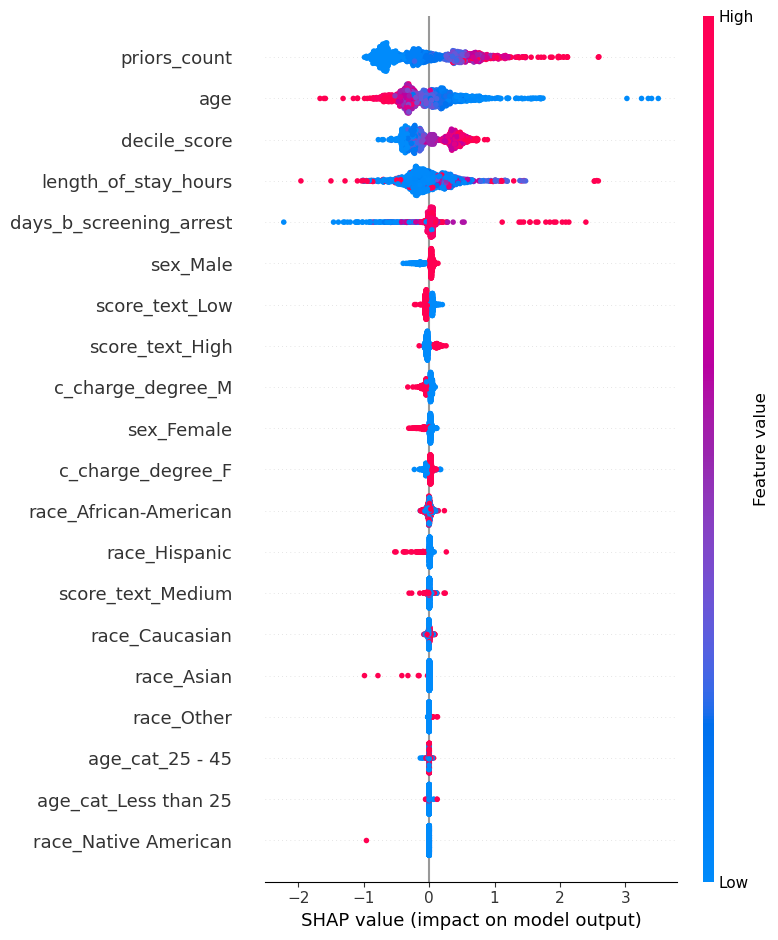

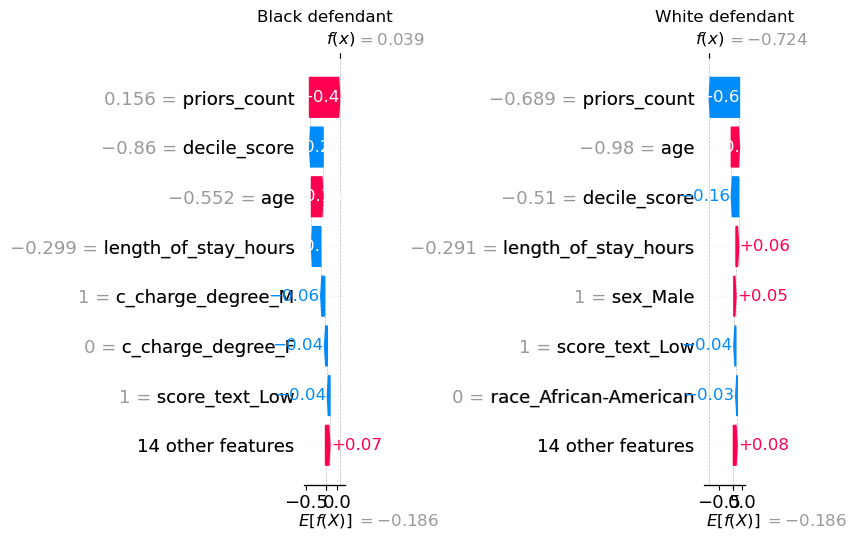

In [224]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Get fitted preprocessor and classifier from the pipeline
fitted_preprocessor = gbt_pipeline.named_steps["preprocessor"] # Get the fitted preprocessor from the pipeline
fitted_classifier = gbt_pipeline.named_steps["classifier"] # Get the fitted classifier from the pipeline

# Encode the test set using the fitted preprocessor
X_test_enc = fitted_preprocessor.transform(X_test)
X_test_enc_dense = X_test_enc.toarray() if hasattr(X_test_enc, "toarray") else np.asarray(X_test_enc) # Convert to dense if sparse  

# Build feature names for SHAP
cat_feature_names = list(
    fitted_preprocessor.named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(category_features)
)
# numeric_features are unchanged, categorical features are expanded by one-hot encoding
feat_names = numeric_features + cat_feature_names # Build the full list of feature names after encoding

# Compute SHAP values using TreeExplainer (works with tree-based models like GradientBoostingClassifier)
explainer_shap = shap.TreeExplainer(fitted_classifier) # Create SHAP TreeExplainer using the fitted classifier
shap_values = explainer_shap.shap_values(X_test_enc_dense) # Compute SHAP values for the encoded test set

# For binary classification, shap_values is a list with two arrays (one per class). We take the one for the positive class (index 1).
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
    expected_value = explainer_shap.expected_value[1]
else:
    shap_values_plot = shap_values
    expected_value = explainer_shap.expected_value

# Generate SHAP summary plot for the test set
shap.summary_plot(shap_values_plot, X_test_enc_dense, feature_names=feat_names) # Create a SHAP summary plot for the test set

# Generate SHAP waterfall plots for the selected Black and White defendants
black_loc = X_test.index.get_loc(black_idx) # Get the integer location of the selected Black defendant in X_test
white_loc = X_test.index.get_loc(white_idx) # Get the integer location of the selected White defendant in X_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loop through the two defendants and create a waterfall plot for each
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    explanation = shap.Explanation(
        values=shap_values_plot[loc],
        base_values=expected_value,
        data=X_test_enc_dense[loc],
        feature_names=feat_names
    )
    shap.plots.waterfall(explanation, max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the SHAP waterfall plots for the selected defendants

### Step 8 — Counterfactuals with DiCE: Black vs White

In this section, we generate DiCE counterfactual explanations for the same Black and White defendants we analyzed with LIME and SHAP. This shows how different explanation methods can provide complementary insights about model behavior and potential biases. Hence, we will use the same GBT model and the same test instances (black_idx and white_idx) to generate counterfactuals with DiCE. The counterfactuals will show how the model's prediction would change if certain features were altered, which can help us understand the decision boundaries and potential biases in the model.

In [225]:
# !pip install dice-ml
import pandas as pd
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numeric_features,
    outcome_name=target
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx), ("White defendant", white_idx)]:
    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs=3,
        desired_class="opposite",
        permitted_range={
            "age": [18, 70],
            "priors_count": [0, 38]
        },
        features_to_vary=["age", "priors_count", "c_charge_degree"]
    )

    print(f"\nDiCE counterfactuals: {label}")
    print(cf.cf_examples_list[0].final_cfs_df)

100%|██████████| 1/1 [00:00<00:00, 25.64it/s]



DiCE counterfactuals: Black defendant
   age  priors_count  days_b_screening_arrest  decile_score  \
0   45             3                     -1.0             2   
1   52             4                     -1.0             2   
2   21             0                     -1.0             2   

   length_of_stay_hours c_charge_degree              race  age_cat score_text  \
0             22.997222               M  African-American  25 - 45        Low   
1             22.997222               M  African-American  25 - 45        Low   
2             22.997222               M  African-American  25 - 45        Low   

    sex  two_year_recid  
0  Male               0  
1  Male               0  
2  Male               0  


100%|██████████| 1/1 [00:00<00:00, 27.62it/s]


DiCE counterfactuals: White defendant
   age  priors_count  days_b_screening_arrest  decile_score  \
0   41            14                     -1.0             3   
1   44            34                     -1.0             3   
2   31            10                     -1.0             3   

   length_of_stay_hours c_charge_degree       race       age_cat score_text  \
0             31.420833               F  Caucasian  Less than 25        Low   
1             31.420833               F  Caucasian  Less than 25        Low   
2             31.420833               F  Caucasian  Less than 25        Low   

    sex  two_year_recid  
0  Male               1  
1  Male               1  
2  Male               1  


## Step 9: Governance Memo – Model Behavior, Limitations, and Monitoring Recommendations

This memo summarizes findings from our evaluation of a recidivism prediction model built using demographic, criminal history, and COMPAS-related features.


- Model Behavior Insights

Across logistic regression and gradient boosting models, predictions are strongly influenced by prior criminal history (e.g., `priors_count`) and COMPAS-derived scores (`decile_score`, `score_text`). Explainability techniques—including LIME, SHAP, and DiCE—consistently show these variables as dominant drivers of predicted risk. While demographic attributes (e.g., race, age category) are not always the top predictors, subgroup analysis reveals disparities in error rates. Specifically, false positive and false negative rates differ across racial groups, indicating uneven model performance. Counterfactual analysis further suggests that small changes in certain features (e.g., priors count or charge degree) can significantly alter outcomes, highlighting sensitivity in decision boundaries.

- Limitations of Methods

Each explanation method has constraints. LIME provides local approximations that may be unstable depending on sampling. SHAP offers more consistent global and local explanations but assumes feature independence in some configurations. DiCE counterfactuals depend on feasible feature constraints; unrealistic changes (e.g., age adjustments) can produce misleading insights if not carefully restricted. Additionally, preprocessing steps (e.g., one-hot encoding) reduce interpretability of individual features. Importantly, observational data may encode historical biases, which the model can inadvertently learn.

- Monitoring Recommendations

We recommend continuous monitoring of model performance across demographic subgroups, including tracking false positive/negative rates and calibration over time. Periodic fairness audits should be conducted using multiple metrics (e.g., equal opportunity, demographic parity). Feature importance and explanation outputs should be reviewed regularly to detect drift or unintended reliance on sensitive attributes. Finally, governance controls should include documented model updates, reproducibility checks, and clear guidelines on permissible use, ensuring alignment with legal and ethical standards.


## Conclusion Statement 

In this assignment we carried out a comprehensive analysis of the `COMPAS-based modeling pipeline` demonstrates that while modern machine learning techniques can achieve reasonable predictive performance in estimating recidivism risk, they also surface important concerns around fairness, interpretability, and reliability. Across logistic regression and gradient boosting models, predictions are consistently driven by criminal history variables (e.g., prior offenses) and COMPAS-derived scores, indicating that the models capture meaningful signals related to risk. However, subgroup evaluations reveal disparities in error rates across racial groups, particularly in false positive and false negative outcomes, suggesting uneven model behavior.

We used an explainability techniques including `LIME`, `SHAP`, and `counterfactual analysis (DiCE)` that provides valuable insight into both `global` and `individual-level` decision patterns. These methods confirm that small changes in certain features can materially alter predictions, highlighting sensitivity and potential instability in edge cases. At the same time, they expose limitations: local explanations may vary, global explanations rely on assumptions, and counterfactuals can become unrealistic without strict constraints.

Overall, our findings emphasize that predictive accuracy alone is insufficient for deployment in high-stakes judicial contexts. Any use of such models must be accompanied by rigorous governance, continuous fairness monitoring, and transparent documentation. The COMPAS analysis ultimately underscores a critical principle such as `risk assessment tools` should support and not replace human judgment, and must be applied with caution, accountability, and ongoing oversight to mitigate bias and unintended harm.
